# Supplementary Material — 2. Evaluation

Combined evaluation of the predictions saved by `01_generate_probabilities.ipynb`,
**pooled across all five 2015/16 European top leagues** (1822 league matches).

## Sections
1. Outcome-probability evaluation: Brier, RPS, calibration plots — including the
   pre-match Bet365 baseline.
2. Exact-score evaluation: empirical bars + jittered model markers for goal,
   total-goal and top-10 scoreline distributions; per-approach predicted
   scoreline heatmaps and their deviations from the empirical distribution;
   TVD and KL divergence summarised in a table and a bar chart.

All plots are produced with **seaborn**.

In [27]:
import sys
from collections import defaultdict
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'modules'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loading import load_competition_data
from evaluation import (
    compute_scoring_rules,
    bootstrap_outcome_metrics,
    bootstrap_gof_metrics,
    aggregate_score_distributions,
    compute_empirical_distributions,
    compute_gof_metrics,
)

sns.set_theme(context='notebook', style='whitegrid')

INPUT_DIR  = Path('..') / '..' / 'data' / 'input_data'
PRED_DIR   = Path('output')
FIG_DIR    = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

LEAGUES = ['epl_1516', 'bundesliga_1516', 'laliga_1516', 'seriea_1516', 'ligue1_1516']
OUTCOME_APPROACHES = ['poisson_binomial', 'double_poisson',
                      'bivariate_poisson', 'dixon_coles', 'betting_odds']
SCORE_APPROACHES   = ['poisson_binomial', 'double_poisson',
                      'bivariate_poisson', 'dixon_coles']
MAX_GOALS = 10
MAX_TOTAL = 12
MAX_SC    = 7

# Snake-case slugs are the canonical internal keys (they match parquet
# filenames and the colour/marker dictionaries).  Tables and plots aimed
# at the reader use the title-case display labels in LABELS.
LABELS = {
    'empirical':         'Empirical',
    'poisson_binomial':  'Poisson Binomial',
    'double_poisson':    'Double Poisson',
    'bivariate_poisson': 'Bivariate Poisson',
    'dixon_coles':       'Dixon-Coles',
    'betting_odds':      'Betting Odds',
}
LABEL_TO_SLUG = {v: k for k, v in LABELS.items()}

PALETTE = {
    'empirical':         '#546E7A',
    'poisson_binomial':  '#66BB6A',
    'double_poisson':    '#42A5F5',
    'bivariate_poisson': '#EF5350',
    'dixon_coles':       '#AB47BC',
    'betting_odds':      '#FFA726',
}
MARKERS = {
    'poisson_binomial':  'o',
    'double_poisson':    'D',
    'bivariate_poisson': 's',
    'dixon_coles':       '^',
    'betting_odds':      'v',
}

idx = pd.IndexSlice

## 0. Pool predictions across all five leagues

In [28]:
def _pool(target: str, approaches: list[str]) -> dict[str, pd.DataFrame]:
    pooled: dict[str, list[pd.DataFrame]] = defaultdict(list)
    for slug in LEAGUES:
        for a in approaches:
            path = PRED_DIR / f'{slug}_{a}_{target}.parquet'
            if path.exists():
                pooled[a].append(pd.read_parquet(path))
            else:
                print(f'  Missing: {path.name}')
    return {a: pd.concat(parts, ignore_index=True) for a, parts in pooled.items() if parts}

outcomes = _pool('outcomes', OUTCOME_APPROACHES)
scores   = _pool('scores',   SCORE_APPROACHES)

matches_pooled = pd.concat(
    [load_competition_data(INPUT_DIR / f'{slug}.parquet') for slug in LEAGUES],
    ignore_index=True,
)

n_outcome = {a: len(df) for a, df in outcomes.items()}
n_scores  = {a: len(df) for a, df in scores.items()}
print(f'Pooled match results: {len(matches_pooled)} matches')
print(f'Outcome predictions per approach: {n_outcome}')
print(f'Score predictions per approach:   {n_scores}')

Pooled match results: 1823 matches
Outcome predictions per approach: {'poisson_binomial': 1822, 'double_poisson': 1822, 'bivariate_poisson': 1822, 'dixon_coles': 1822, 'betting_odds': 1822}
Score predictions per approach:   {'poisson_binomial': 1822, 'double_poisson': 1822, 'bivariate_poisson': 1822, 'dixon_coles': 1822}


## 1. Outcome-probability evaluation

All five approaches predict $\big(P(\text{home win}), P(\text{draw}), P(\text{away win})\big)$. The pre-match Bet365 odds, converted to normalised implied probabilities (overround removed), serve as an external benchmark.

We report two strictly proper scoring rules — the **multi-class Brier score** and the **Ranked Probability Score (RPS)** (Constantinou & Fenton, 2012) — and **Expected Calibration Error (ECE)** averaged over the three outcome classes.

In [29]:
scores_table = compute_scoring_rules(outcomes)
scores_table = (
    scores_table.assign(_ord=scores_table['Approach'].map({a: i for i, a in enumerate(OUTCOME_APPROACHES)}))
                .sort_values('_ord')
                .drop(columns='_ord')
                .reset_index(drop=True)
)

# Bootstrap 95% CIs for Brier and RPS (slug-keyed, merged before label mapping)
print('Running bootstrap for outcome metrics (1000 resamples)...')
outcome_ci = bootstrap_outcome_metrics(outcomes, n_bootstrap=1000, rng_seed=42)
scores_table = scores_table.merge(outcome_ci, on='Approach', how='left')
print('Done.')

scores_table['Approach'] = scores_table['Approach'].map(LABELS)
scores_table[['Approach', 'N', 'Brier', 'Brier_lower', 'Brier_upper',
              'RPS', 'RPS_lower', 'RPS_upper']].to_csv('results/evaluation_metrics.csv', index=False)

Running bootstrap for outcome metrics (1000 resamples)...
Done.


In [30]:
#| label: tbl-evaluation-metrics
#| tbl-cap: Scoring rules for each outcome prediction approach with 95% bootstrap CIs (1000 resamples). Lower is better.

tab = scores_table[['Approach', 'N']].copy()
tab['Brier (95% CI)'] = scores_table.apply(
    lambda r: f"{r['Brier']:.3f} [{r['Brier_lower']:.3f}, {r['Brier_upper']:.3f}]", axis=1)
tab['RPS (95% CI)'] = scores_table.apply(
    lambda r: f"{r['RPS']:.3f} [{r['RPS_lower']:.3f}, {r['RPS_upper']:.3f}]", axis=1)

min_brier_idx = scores_table['Brier'].idxmin()
min_rps_idx   = scores_table['RPS'].idxmin()

def _style_min(row):
    styles = [''] * len(row)
    if row.name == min_brier_idx:
        styles[row.index.get_loc('Brier (95% CI)')] = 'font-weight:bold'
    if row.name == min_rps_idx:
        styles[row.index.get_loc('RPS (95% CI)')] = 'font-weight:bold'
    return styles

tab.style.apply(_style_min, axis=1)

,Approach,N,Brier (95% CI),RPS (95% CI)
0,Poisson Binomial,1822,"0.539 [0.520, 0.557]","0.177 [0.170, 0.184]"
1,Double Poisson,1822,"0.541 [0.523, 0.558]","0.177 [0.171, 0.184]"
2,Bivariate Poisson,1822,"0.541 [0.524, 0.559]","0.177 [0.171, 0.184]"
3,Dixon-Coles,1822,"0.541 [0.523, 0.558]","0.177 [0.171, 0.184]"
4,Betting Odds,1822,"0.587 [0.573, 0.601]","0.199 [0.193, 0.205]"


### Reliability diagrams (per outcome class)

Bin matches by predicted probability into deciles and plot the observed event
frequency in each bin against the bin's mean predicted probability.
Points on the diagonal indicate perfect calibration.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


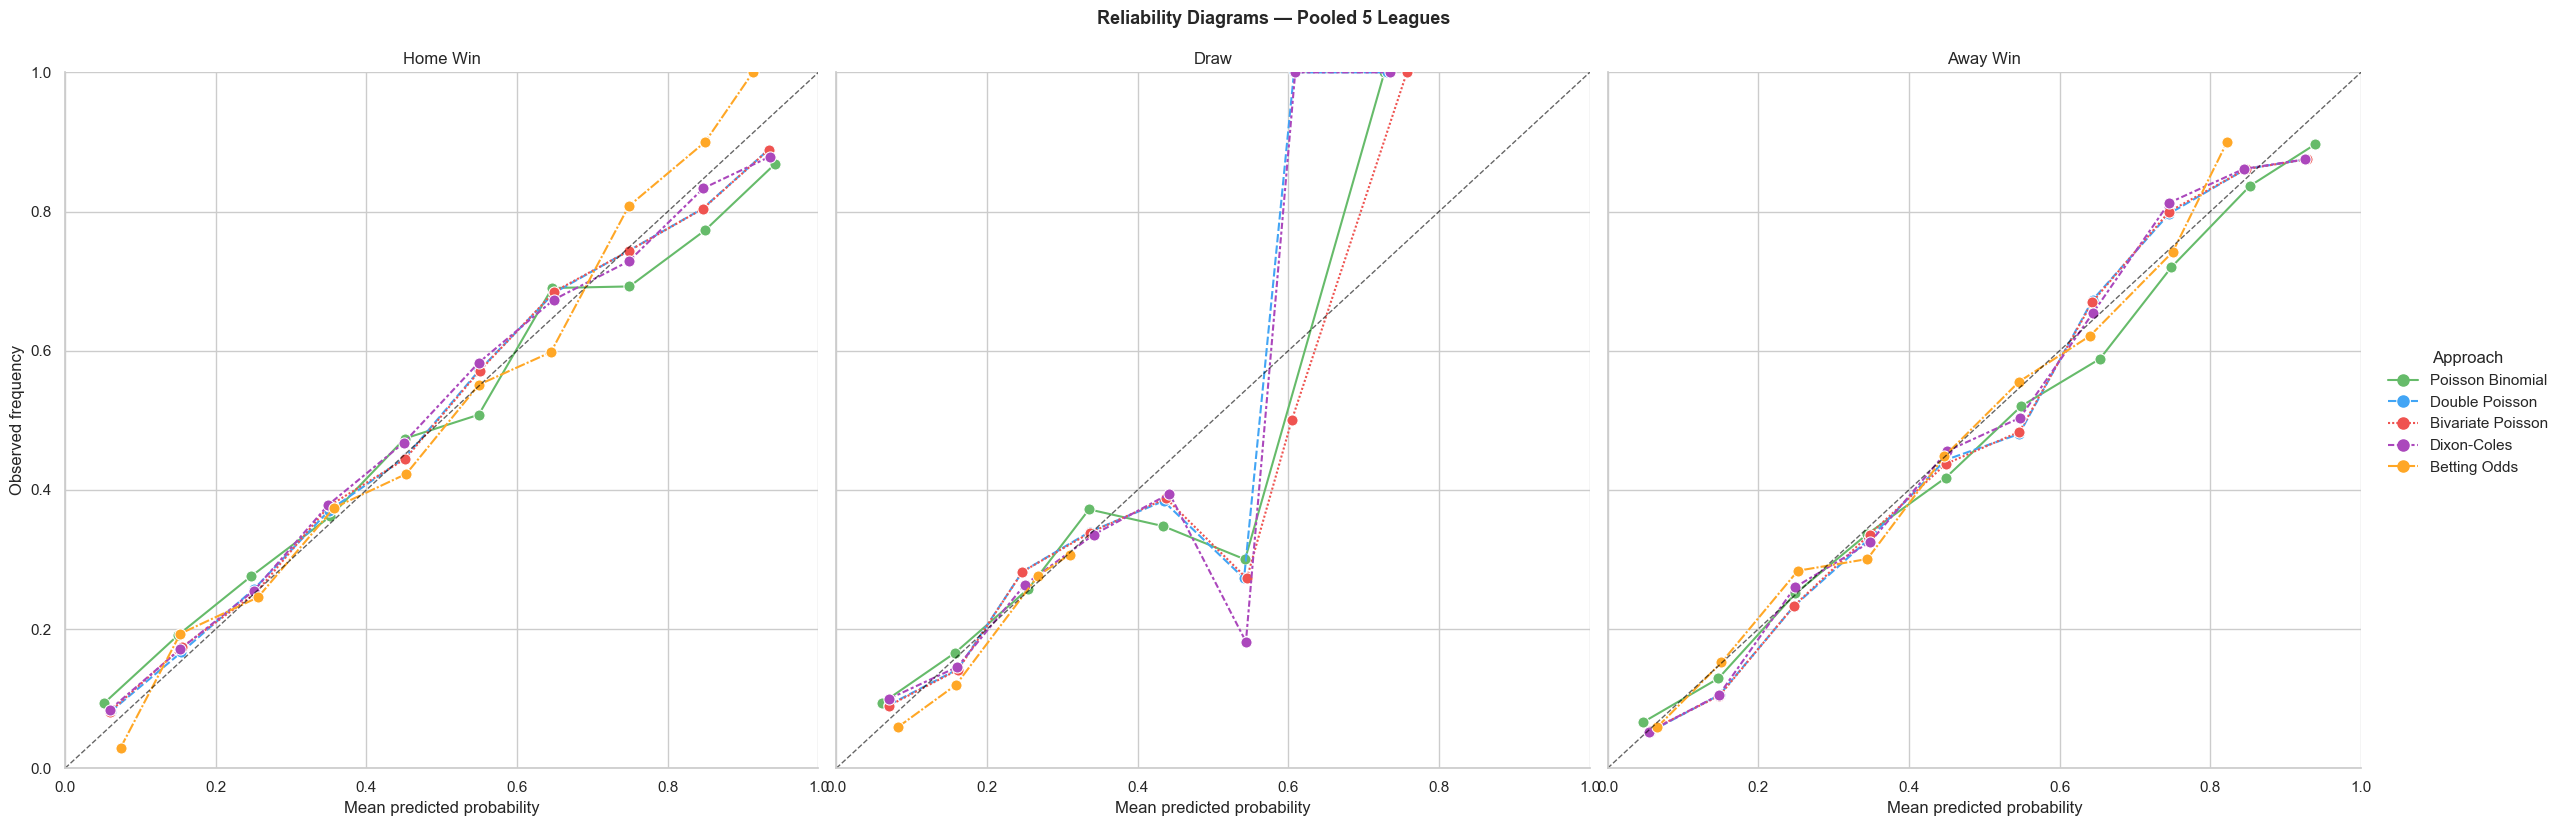

In [31]:
#| label: fig-calibration-curves
#| fig-cap: Reliability diagrams for the three outcome classes, pooled over 1822 matches; Bet365 lies closest to the diagonal but the xG-based models compensate with greater sharpness.
#| fig-height: 8

n_bins   = 10
bin_edge = np.linspace(0, 1, n_bins + 1)
_classes = [('home_win', 'Home Win', 'p_home_win'),
            ('draw',     'Draw',     'p_draw'),
            ('away_win', 'Away Win', 'p_away_win')]

records = []
for name in OUTCOME_APPROACHES:
    if name not in outcomes:
        continue
    df = outcomes[name]
    for outcome, label, prob_col in _classes:
        y_true = (df['actual_outcome'] == outcome).astype(float).values
        y_pred = df[prob_col].astype(float).values
        bin_idx = np.clip(np.digitize(y_pred, bin_edge) - 1, 0, n_bins - 1)
        for m in range(n_bins):
            mask = bin_idx == m
            if not mask.any():
                continue
            records.append({
                'Approach':  LABELS[name],
                'outcome':   label,
                'predicted': float(y_pred[mask].mean()),
                'observed':  float(y_true[mask].mean()),
            })
cal_df = pd.DataFrame(records)

g = sns.relplot(
    data=cal_df, x='predicted', y='observed',
    col='outcome', col_order=[lbl for _, lbl, _ in _classes],
    hue='Approach', hue_order=[LABELS[a] for a in OUTCOME_APPROACHES if a in outcomes],
    style='Approach', kind='line',
    marker='o', markersize=8,
    height=8, aspect=1.0,
    #palette = "viridis",
    palette={LABELS[a]: PALETTE[a] for a in OUTCOME_APPROACHES if a in outcomes},
    facet_kws={'sharex': True, 'sharey': True},
)
for ax in g.axes.flat:
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
g.set_axis_labels('Mean predicted probability', 'Observed frequency')
g.set_titles('{col_name}')
g.fig.suptitle('Reliability Diagrams — Pooled 5 Leagues',
               y=1.03, fontsize=13, fontweight='bold')
g.fig.savefig(FIG_DIR / 'pooled_calibration.eps', dpi=150, bbox_inches='tight')
plt.show()

## 2. Exact-score evaluation

Compare the predicted goal distributions to the empirical distribution observed across the pooled sample.

We begin with a goodness-of-fit summary using **Total Variation Distance (TVD)** — the largest absolute difference any event probability can exhibit between two PMFs — and **Kullback–Leibler divergence (KL)**, which equals (up to a constant) the negative expected log-score of the model relative to the empirical distribution.

Distribution comparisons follow: the empirical distribution is shown as bars; each approach is overlaid as scatter markers with a small horizontal jitter so that closely-clustered points remain visually distinguishable.

In [32]:
empirical   = compute_empirical_distributions(matches_pooled, MAX_GOALS, MAX_TOTAL)
theoretical = {a: aggregate_score_distributions(scores[a], MAX_GOALS, MAX_TOTAL)
               for a in SCORE_APPROACHES if a in scores}

### Goodness-of-fit: TVD and KL divergence

In [33]:
gof = compute_gof_metrics(empirical, theoretical, max_sc=MAX_SC)
gof_slug = gof.copy()           # slug-keyed copy for bootstrap CI merge
gof['Approach'] = gof['Approach'].map(LABELS)
pivot = (
    gof.pivot_table(index='Approach', columns='Distribution', values=['TVD', 'KL'])
       .reindex([LABELS[a] for a in SCORE_APPROACHES if a in theoretical])
       .reindex(columns=[(m, d) for m in ['TVD', 'KL']
                                  for d in ['Home goals', 'Away goals', 'Total goals', 'Exact scorelines']])
)
pivot.columns.names = (None, None)
pivot.round(3).to_csv('results/tvd_kl_results.csv')
pivot.loc[:, idx[:, 'Exact scorelines']].to_csv('results/tvd_kl_results_scoreline.csv')

df_tvd = pivot.loc[:, idx['TVD', :]].round(3)
df_kl  = pivot.loc[:, idx['KL', :]].round(3)

df_tvd.to_csv('results/tvd_results.csv')
df_kl.to_csv('results/kl_results.csv')

pivot.round(3)

TVD                                          \
                  Home goals Away goals Total goals Exact scorelines   
Approach                                                               
Poisson Binomial       0.036      0.027       0.054            0.064   
Double Poisson         0.085      0.087       0.099            0.129   
Bivariate Poisson      0.085      0.087       0.100            0.129   
Dixon-Coles            0.085      0.087       0.094            0.123   

                          KL                                          
                  Home goals Away goals Total goals Exact scorelines  
Approach                                                              
Poisson Binomial       0.007      0.004       0.012            0.023  
Double Poisson         0.022      0.020       0.030            0.055  
Bivariate Poisson      0.022      0.020       0.031            0.055  
Dixon-Coles            0.022      0.020       0.030            0.054

In [34]:
# Bootstrap 95% CIs for TVD and KL (vectorised pre-stacking, ~5-15 seconds)
print('Running bootstrap for GoF metrics (1000 resamples)...')
gof_ci = bootstrap_gof_metrics(
    matches_pooled, scores,
    max_goals=MAX_GOALS, max_total=MAX_TOTAL, max_sc=MAX_SC,
    n_bootstrap=1000, rng_seed=42,
)
print('Done.')

# Map approach labels and merge with label-mapped point estimates
gof_ci['Approach'] = gof_ci['Approach'].map(LABELS)
gof_with_ci = gof.merge(gof_ci, on=['Approach', 'Distribution'], how='left')

Running bootstrap for GoF metrics (1000 resamples)...
Done.


In [35]:
#| label: tbl-tvd-results
#| tbl-cap: Total Variation Distance (95% bootstrap CI) between pooled model-predicted and empirical distributions. Lower is better.

dists     = ['Home goals', 'Away goals', 'Total goals', 'Exact scorelines']
app_order = [LABELS[a] for a in SCORE_APPROACHES if a in theoretical]

# Build display table with "point [lower, upper]" format
display_tvd = pd.DataFrame(index=app_order, columns=dists, dtype=object)
display_tvd.index.name = 'Approach'
for app in app_order:
    for d in dists:
        row = gof_with_ci[(gof_with_ci['Approach'] == app) & (gof_with_ci['Distribution'] == d)].iloc[0]
        display_tvd.loc[app, d] = (
            f"{row['TVD']:.3f} [{row['TVD_lower']:.3f}, {row['TVD_upper']:.3f}]"
        )

# Identify minimum-TVD approach per distribution for bolding
min_tvd_idx = {
    d: gof_with_ci[gof_with_ci['Distribution'] == d].set_index('Approach')['TVD'].idxmin()
    for d in dists
}

def _bold_min_tvd(row):
    return [
        'font-weight:bold' if row.name == min_tvd_idx[d] else ''
        for d in dists
    ]

display_tvd.style.apply(_bold_min_tvd, axis=1)

,Home goals,Away goals,Total goals,Exact scorelines
Approach,,,,
Poisson Binomial,"0.036 [0.024, 0.057]","0.027 [0.017, 0.051]","0.054 [0.040, 0.076]","0.064 [0.063, 0.096]"
Double Poisson,"0.085 [0.068, 0.106]","0.087 [0.069, 0.107]","0.099 [0.083, 0.120]","0.129 [0.117, 0.156]"
Bivariate Poisson,"0.085 [0.068, 0.106]","0.087 [0.069, 0.107]","0.100 [0.084, 0.121]","0.129 [0.117, 0.156]"
Dixon-Coles,"0.085 [0.068, 0.106]","0.087 [0.069, 0.107]","0.093 [0.078, 0.114]","0.123 [0.111, 0.150]"


In [36]:
#| label: tbl-kl-results
#| tbl-cap: Kullback--Leibler divergence (95% bootstrap CI) between pooled model-predicted and empirical distributions. Lower is better.

display_kl = pd.DataFrame(index=app_order, columns=dists, dtype=object)
display_kl.index.name = 'Approach'
for app in app_order:
    for d in dists:
        row = gof_with_ci[(gof_with_ci['Approach'] == app) & (gof_with_ci['Distribution'] == d)].iloc[0]
        display_kl.loc[app, d] = (
            f"{row['KL']:.3f} [{row['KL_lower']:.3f}, {row['KL_upper']:.3f}]"
        )

min_kl_idx = {
    d: gof_with_ci[gof_with_ci['Distribution'] == d].set_index('Approach')['KL'].idxmin()
    for d in dists
}

def _bold_min_kl(row):
    return [
        'font-weight:bold' if row.name == min_kl_idx[d] else ''
        for d in dists
    ]

display_kl.style.apply(_bold_min_kl, axis=1)

,Home goals,Away goals,Total goals,Exact scorelines
Approach,,,,
Poisson Binomial,"0.007 [0.004, 0.014]","0.004 [0.003, 0.012]","0.012 [0.008, 0.022]","0.023 [0.024, 0.042]"
Double Poisson,"0.022 [0.016, 0.032]","0.020 [0.015, 0.031]","0.030 [0.024, 0.044]","0.055 [0.052, 0.078]"
Bivariate Poisson,"0.022 [0.016, 0.032]","0.020 [0.015, 0.031]","0.031 [0.024, 0.044]","0.055 [0.052, 0.078]"
Dixon-Coles,"0.022 [0.016, 0.032]","0.020 [0.015, 0.031]","0.030 [0.024, 0.043]","0.054 [0.051, 0.077]"


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


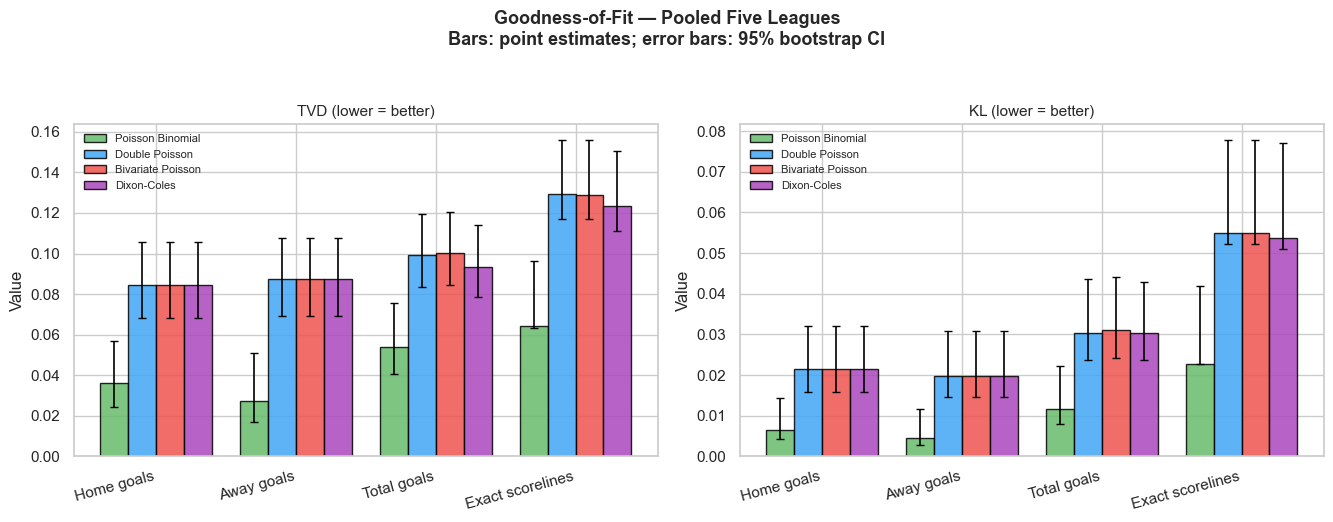

In [37]:
dists_order = ['Home goals', 'Away goals', 'Total goals', 'Exact scorelines']
app_order   = [LABELS[a] for a in SCORE_APPROACHES if a in theoretical]
n_apps      = len(app_order)
x           = np.arange(len(dists_order))
width       = 0.8 / n_apps

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=False)
for col_idx, metric in enumerate(['TVD', 'KL']):
    ax = axes[col_idx]
    for i, app in enumerate(app_order):
        slug = LABEL_TO_SLUG[app]
        vals, err_lo, err_hi = [], [], []
        for d in dists_order:
            row = gof_with_ci[
                (gof_with_ci['Approach'] == app) & (gof_with_ci['Distribution'] == d)
            ].iloc[0]
            v = row[metric]
            vals.append(v)
            err_lo.append(max(0.0, v - row[f'{metric}_lower']))
            err_hi.append(max(0.0, row[f'{metric}_upper'] - v))

        offset = (i - n_apps / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=app,
               color=PALETTE.get(slug, '#8D6E63'), alpha=0.85, edgecolor='black')
        ax.errorbar(x + offset, vals, yerr=[err_lo, err_hi],
                    fmt='none', color='black', capsize=3, linewidth=1.2, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(dists_order, rotation=15, ha='right')
    ax.set_title(f'{metric} (lower = better)', fontsize=11)
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)

fig.suptitle(
    'Goodness-of-Fit — Pooled Five Leagues\n'
    'Bars: point estimates; error bars: 95% bootstrap CI',
    y=1.04, fontsize=13, fontweight='bold',
)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_gof_summary.eps', dpi=150, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


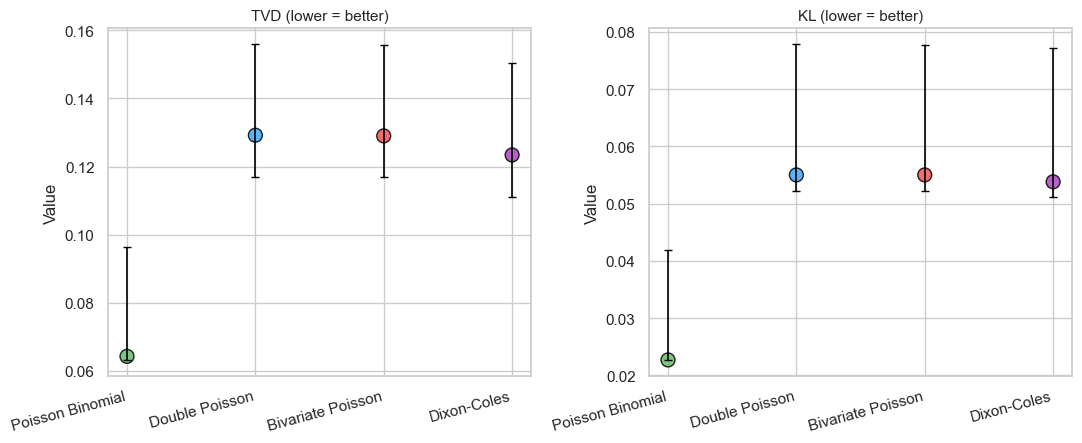

In [38]:
#| label: fig-gof-scoreline-scatter
#| fig-cap: TVD and KL for exact scorelines under the four approaches with 95% bootstrap CIs. Lower values indicate a better fit with the empirical distribution.

sc_gof    = gof_with_ci[gof_with_ci['Distribution'] == 'Exact scorelines'].copy()
app_order = [LABELS[a] for a in SCORE_APPROACHES if a in theoretical]
x         = np.arange(len(app_order))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=False)
for col_idx, metric in enumerate(['TVD', 'KL']):
    ax = axes[col_idx]
    vals, err_lo, err_hi, colors = [], [], [], []
    for app in app_order:
        row = sc_gof[sc_gof['Approach'] == app].iloc[0]
        v = row[metric]
        vals.append(v)
        err_lo.append(max(0.0, v - row[f'{metric}_lower']))
        err_hi.append(max(0.0, row[f'{metric}_upper'] - v))
        colors.append(PALETTE.get(LABEL_TO_SLUG[app], '#8D6E63'))

    ax.scatter(x, vals, color=colors, alpha=0.85, edgecolor='black', s=100)
    ax.errorbar(x, vals, yerr=[err_lo, err_hi],
                fmt='none', color='black', capsize=3, linewidth=1.2, zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels(app_order, rotation=15, ha='right')
    ax.set_title(f'{metric} (lower = better)', fontsize=11)
    ax.set_ylabel('Value')

#fig.suptitle(
#    'Exact Scoreline GoF — Pooled Five Leagues\n'
#    'Scatter points: point estimates; error bars: 95% bootstrap CI',
#    y=1.04, fontsize=13, fontweight='bold',
#)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_gof_summary_exact_scoreline.eps', dpi=150, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


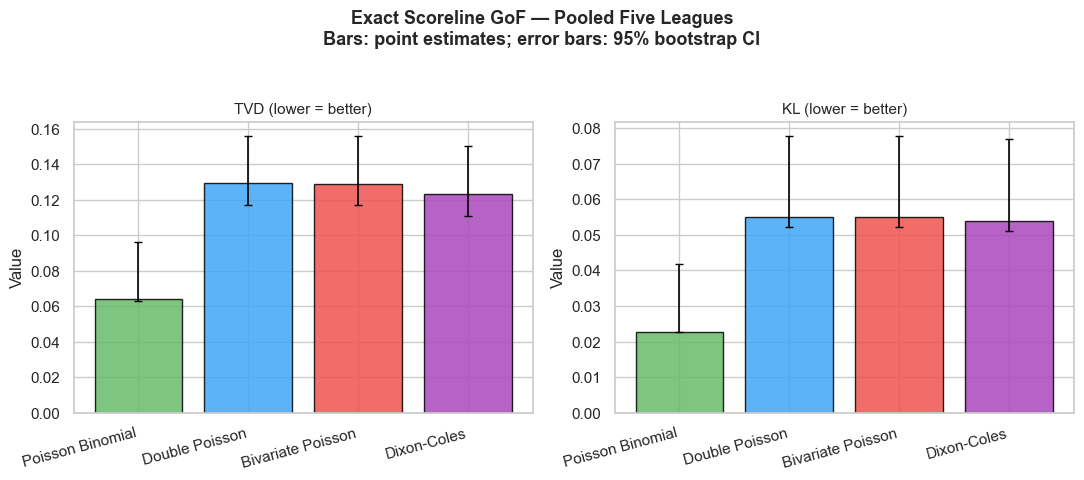

In [39]:
#| label: fig-gof-scoreline
#| fig-cap: TVD and KL for exact scorelines under the four approaches with 95% bootstrap CIs. Lower bars indicate a better fit with the empirical distribution.

sc_gof    = gof_with_ci[gof_with_ci['Distribution'] == 'Exact scorelines'].copy()
app_order = [LABELS[a] for a in SCORE_APPROACHES if a in theoretical]
x         = np.arange(len(app_order))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=False)
for col_idx, metric in enumerate(['TVD', 'KL']):
    ax = axes[col_idx]
    vals, err_lo, err_hi, colors = [], [], [], []
    for app in app_order:
        row = sc_gof[sc_gof['Approach'] == app].iloc[0]
        v = row[metric]
        vals.append(v)
        err_lo.append(max(0.0, v - row[f'{metric}_lower']))
        err_hi.append(max(0.0, row[f'{metric}_upper'] - v))
        colors.append(PALETTE.get(LABEL_TO_SLUG[app], '#8D6E63'))

    ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='black')
    ax.errorbar(x, vals, yerr=[err_lo, err_hi],
                fmt='none', color='black', capsize=3, linewidth=1.2, zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels(app_order, rotation=15, ha='right')
    ax.set_title(f'{metric} (lower = better)', fontsize=11)
    ax.set_ylabel('Value')

fig.suptitle(
    'Exact Scoreline GoF — Pooled Five Leagues\n'
    'Bars: point estimates; error bars: 95% bootstrap CI',
    y=1.04, fontsize=13, fontweight='bold',
)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_gof_summary_exact_scoreline.eps', dpi=150, bbox_inches='tight')
plt.show()

### Goals per team and total goals

Empirical PMFs as bars (`sns.barplot`); each approach overlaid as a
horizontally-jittered scatter (`sns.scatterplot`).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


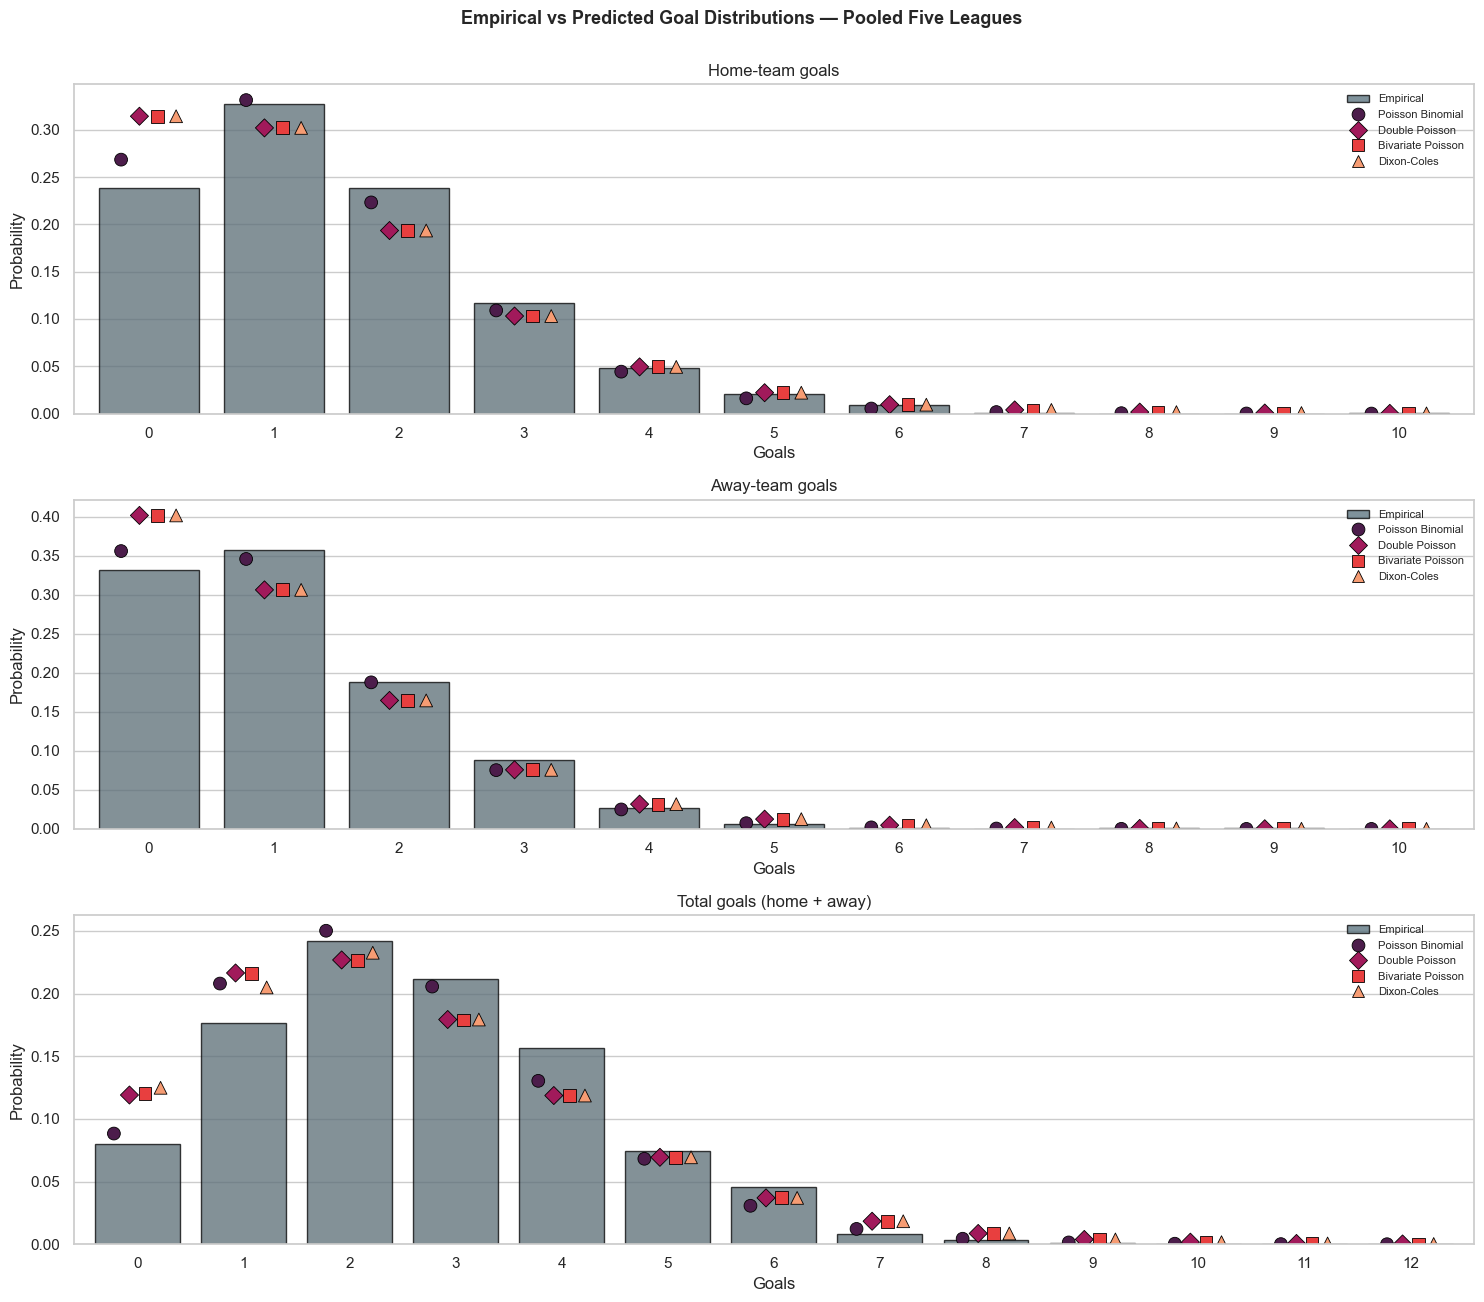

In [40]:
from matplotlib.patches import Patch

def _plot_dist(empirical, theoretical_dict, ax, title, xlabel='Goals'):
    n = len(empirical)

    sns.barplot(
        x=np.arange(n), y=empirical,
        color=PALETTE['empirical'], alpha=0.75, edgecolor='black',
        ax=ax,
    )

    keys     = list(theoretical_dict)
    n_models = len(keys)
    offsets  = np.linspace(-0.22, 0.22, max(n_models, 1))
    rows = []
    for i, name in enumerate(keys):
        for k, p in enumerate(theoretical_dict[name]):
            rows.append({'x': k + offsets[i], 'p': float(p), 'Approach': LABELS[name]})
    mdf = pd.DataFrame(rows)
    sns.scatterplot(
        data=mdf, x='x', y='p',
        hue='Approach', hue_order=[LABELS[a] for a in keys],
        style='Approach',
        markers={LABELS[a]: MARKERS[a] for a in keys},
        palette = "rocket",
        #palette={LABELS[a]: PALETTE[a] for a in keys},
        s=85, edgecolor='black', linewidth=0.6,
        ax=ax, legend='brief',
    )

    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([str(k) for k in range(n)])
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_xlabel(xlabel); ax.set_ylabel('Probability'); ax.set_title(title)

    leg = ax.get_legend()
    handles = [Patch(facecolor=PALETTE['empirical'], alpha=0.75, edgecolor='black',
                     label=LABELS['empirical'])]
    labels  = [LABELS['empirical']]
    if leg is not None:
        handles += list(leg.legend_handles)
        labels  += [t.get_text() for t in leg.get_texts()]
    ax.legend(handles=handles, labels=labels, fontsize=8, loc='upper right')

fig, axes = plt.subplots(3, 1, figsize=(15, 13))
_plot_dist(empirical['home'],  {a: theoretical[a]['home']  for a in SCORE_APPROACHES if a in theoretical}, axes[0], 'Home-team goals')
_plot_dist(empirical['away'],  {a: theoretical[a]['away']  for a in SCORE_APPROACHES if a in theoretical}, axes[1], 'Away-team goals')
_plot_dist(empirical['total'], {a: theoretical[a]['total'] for a in SCORE_APPROACHES if a in theoretical}, axes[2], 'Total goals (home + away)')
fig.suptitle('Empirical vs Predicted Goal Distributions — Pooled Five Leagues',
             fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_goal_distributions.eps', dpi=150, bbox_inches='tight')
plt.show()

### Top-10 most frequent scorelines

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


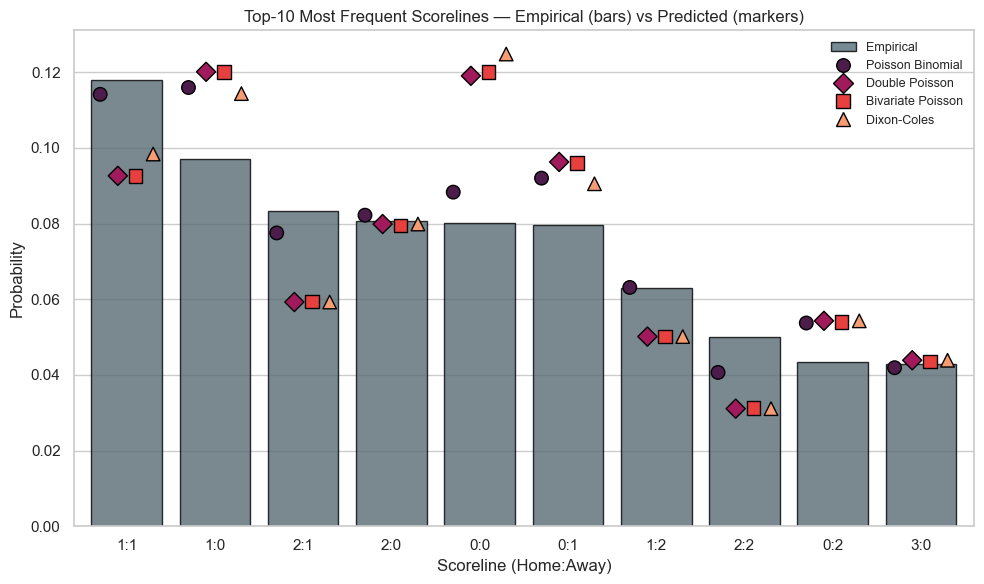

In [41]:
#| label: fig-top-scorelines
#| fig-cap: Top-10 most frequent scorelines in the pooled data, comparing empirical frequencies (bars) with model predictions (markers).

n_goals = empirical['matrix'].shape[0]
rec = []
for h in range(n_goals):
    for a in range(n_goals):
        rec.append({'scoreline': f'{h}:{a}', 'h': h, 'a': a,
                    'empirical': float(empirical['matrix'][h, a])})
sl_df = pd.DataFrame(rec).sort_values('empirical', ascending=False).head(10).reset_index(drop=True)
for name in SCORE_APPROACHES:
    if name not in theoretical:
        continue
    m = theoretical[name]['matrix']
    sl_df[name] = [float(m[r['h'], r['a']]) for _, r in sl_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos  = np.arange(len(sl_df))
labels = sl_df['scoreline'].tolist()

sns.barplot(x=x_pos, y=sl_df['empirical'].values,
            color=PALETTE['empirical'], alpha=0.80, edgecolor='black', ax=ax)

keys     = [a for a in SCORE_APPROACHES if a in theoretical]
n_models = len(keys)
offsets  = np.linspace(-0.30, 0.30, max(n_models, 1))
rows = []
for i, name in enumerate(keys):
    for k in range(len(sl_df)):
        rows.append({'x': k + offsets[i], 'p': float(sl_df.iloc[k][name]),
                     'Approach': LABELS[name]})
mdf = pd.DataFrame(rows)
sns.scatterplot(
    data=mdf, x='x', y='p',
    hue='Approach', hue_order=[LABELS[a] for a in keys],
    style='Approach',
    markers={LABELS[a]: MARKERS[a] for a in keys},
    #palette={LABELS[a]: PALETTE[a] for a in keys},
    palette="rocket",
    s=95, edgecolor='black', linewidth=1, ax=ax, legend='brief',
)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, ha='center')
ax.set_xlim(-0.6, len(sl_df) - 0.4)
ax.set_xlabel('Scoreline (Home:Away)'); ax.set_ylabel('Probability')
ax.set_title('Top-10 Most Frequent Scorelines — Empirical (bars) vs Predicted (markers)')

leg = ax.get_legend()
handles = [Patch(facecolor=PALETTE['empirical'], alpha=0.80, edgecolor='black',
                 label=LABELS['empirical'])]
labels_ = [LABELS['empirical']]
if leg is not None:
    handles += list(leg.legend_handles)
    labels_ += [t.get_text() for t in leg.get_texts()]
ax.legend(handles=handles, labels=labels_, fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_top_scorelines.eps', dpi=150, bbox_inches='tight')
plt.show()

### Per-approach scoreline heatmaps and deviations from empirical

A 4 × 2 grid in which each row corresponds to one prediction approach.
The **left column** shows that approach's expected scoreline frequencies
(predicted joint PMF, in percentage points) over the 0–7 × 0–7 corner of
the joint goal grid. The **right column** shows the per-cell deviation
from the empirical scoreline distribution, predicted minus empirical, in
percentage points; red cells denote over-prediction by the model and blue
cells denote under-prediction. Both colour scales are shared across all
four rows so the panels are directly comparable.

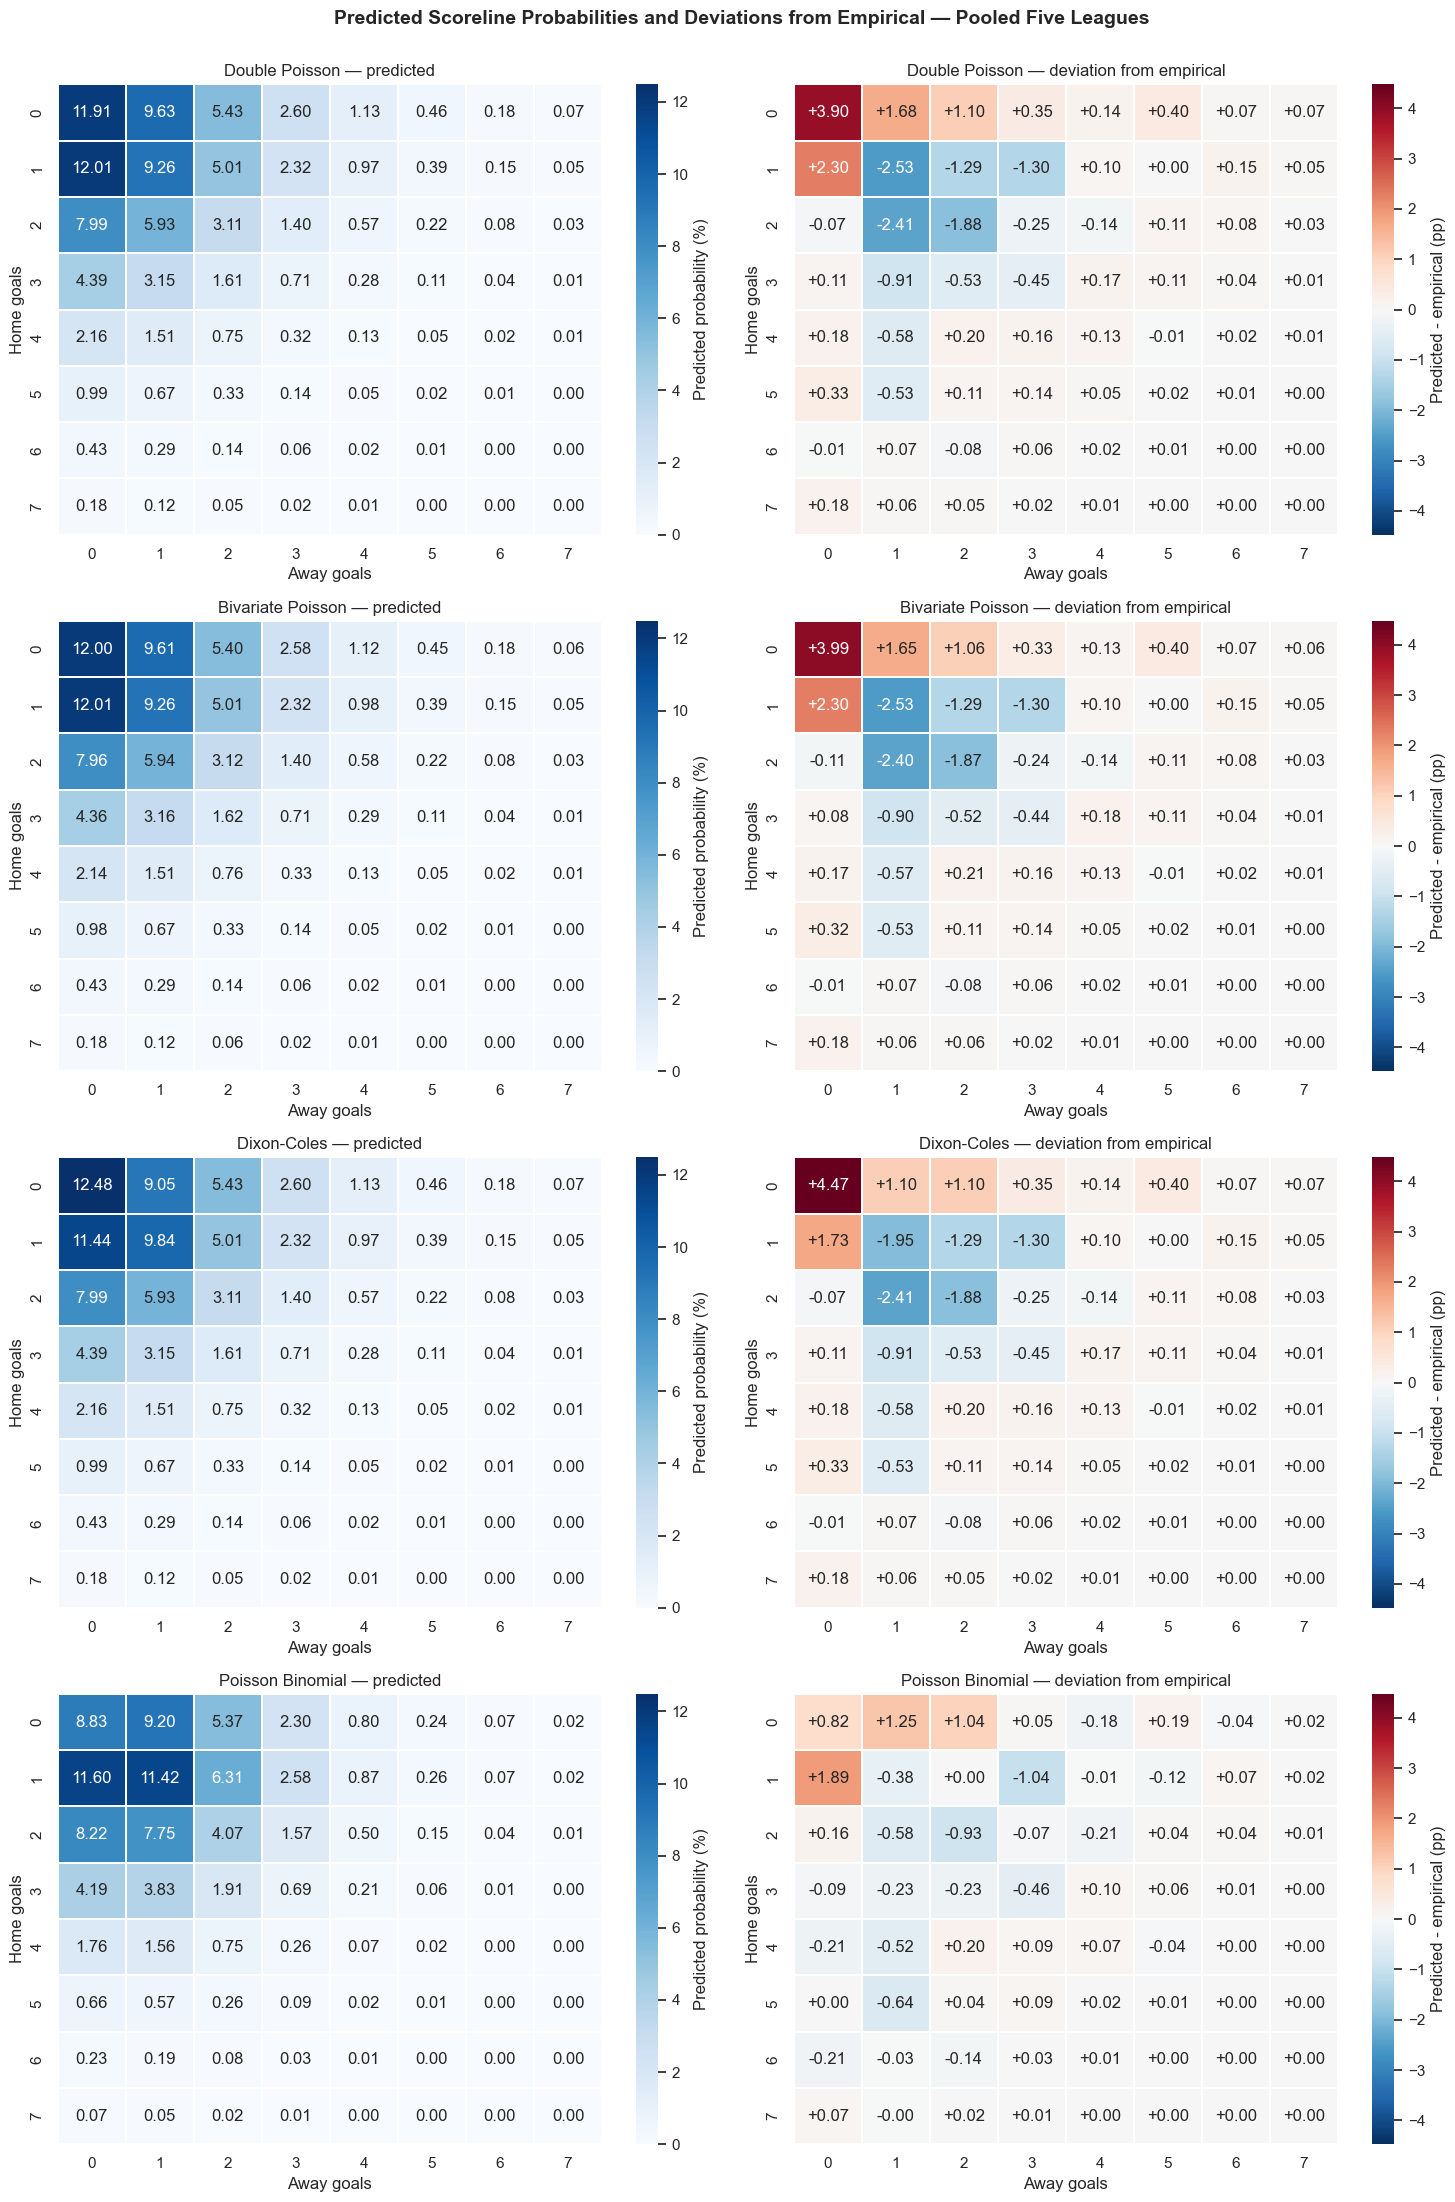

In [42]:
ROW_ORDER = ['double_poisson', 'bivariate_poisson', 'dixon_coles', 'poisson_binomial']
DISPLAY = MAX_SC + 1   # 0..7 on each axis

emp_pct  = empirical['matrix'][:DISPLAY, :DISPLAY] * 100.0
pred_pct = {a: theoretical[a]['matrix'][:DISPLAY, :DISPLAY] * 100.0 for a in ROW_ORDER}
diff_pct = {a: pred_pct[a] - emp_pct for a in ROW_ORDER}

vmax_pred = max(p.max() for p in pred_pct.values())
vabs_diff = max(np.max(np.abs(d)) for d in diff_pct.values())

def _draw_row(approach, ax_pred, ax_diff):
    sns.heatmap(
        pred_pct[approach],
        ax=ax_pred, annot=True, fmt='.2f',
        cmap='Blues', vmin=0, vmax=vmax_pred,
        xticklabels=range(DISPLAY), yticklabels=range(DISPLAY),
        cbar_kws={'label': 'Predicted probability (%)'},
        linewidths=0.3, linecolor='white',
    )
    ax_pred.set_title(f'{LABELS[approach]} — predicted')
    ax_pred.set_xlabel('Away goals'); ax_pred.set_ylabel('Home goals')

    sns.heatmap(
        diff_pct[approach],
        ax=ax_diff, annot=True, fmt='+.2f',
        cmap='RdBu_r', center=0, vmin=-vabs_diff, vmax=vabs_diff,
        xticklabels=range(DISPLAY), yticklabels=range(DISPLAY),
        cbar_kws={'label': 'Predicted - empirical (pp)'},
        linewidths=0.3, linecolor='white',
    )
    ax_diff.set_title(f'{LABELS[approach]} — deviation from empirical')
    ax_diff.set_xlabel('Away goals'); ax_diff.set_ylabel('Home goals')

# Individual EPS files per approach
for approach in ROW_ORDER:
    fig_row, axes_row = plt.subplots(1, 2, figsize=(15, 5.5))
    _draw_row(approach, axes_row[0], axes_row[1])
    fig_row.tight_layout()
    fig_row.savefig(FIG_DIR / f'pooled_scoreline_heatmaps_{approach}.eps', dpi=150, bbox_inches='tight')
    plt.close(fig_row)

# Combined figure
fig, axes = plt.subplots(4, 2, figsize=(15, 22))
for i, approach in enumerate(ROW_ORDER):
    _draw_row(approach, axes[i, 0], axes[i, 1])

fig.suptitle('Predicted Scoreline Probabilities and Deviations from Empirical — Pooled Five Leagues',
             fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pooled_scoreline_heatmaps.eps', dpi=150, bbox_inches='tight')
plt.show()

### Focused comparison: Poisson Binomial vs. Dixon-Coles

For illustrative purposes, we highlight the deviation heatmaps of the two best-performing approaches side by side. Dixon-Coles is selected as the sole representative of the Poisson-count family because it is the closest competitor to the Poisson Binomial model across all goodness-of-fit metrics. Showing only these two approaches keeps the comparison uncluttered and makes the structural differences in their mis-predictions immediately visible.

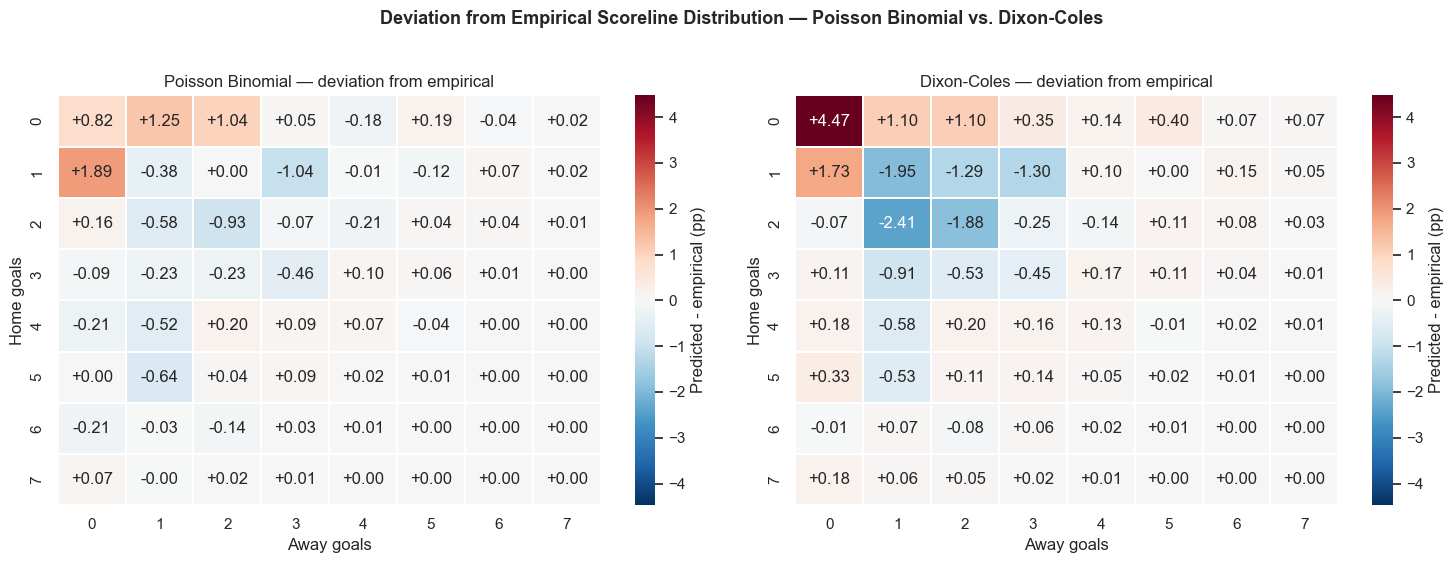

In [43]:
#| label: fig-scoreline-heatmaps
#| fig-cap: Heatmaps of predicted scoreline probabilities and deviations from empirical, comparing Poisson Binomial and Dixon-Coles approaches. 
# The Poisson Binomial approach shows a closer fit to the empirical distribution, particularly for low-scoring outcomes, while Dixon-Coles tends 
# to especially overestimate the probabilities of 0:0 scorelines.
#| fig-height: 10

COMPARE = ['poisson_binomial', 'dixon_coles']

fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, approach in zip(axes_cmp, COMPARE):
    sns.heatmap(
        diff_pct[approach],
        ax=ax, annot=True, fmt='+.2f',
        cmap='RdBu_r', center=0, vmin=-vabs_diff, vmax=vabs_diff,
        xticklabels=range(DISPLAY), yticklabels=range(DISPLAY),
        cbar_kws={'label': 'Predicted - empirical (pp)'},
        linewidths=0.3, linecolor='white',
    )
    ax.set_title(f'{LABELS[approach]} — deviation from empirical')
    ax.set_xlabel('Away goals'); ax.set_ylabel('Home goals')

fig_cmp.suptitle('Deviation from Empirical Scoreline Distribution — Poisson Binomial vs. Dixon-Coles',
                 fontsize=13, fontweight='bold', y=1.02)
fig_cmp.tight_layout()
fig_cmp.savefig(FIG_DIR / 'pooled_scoreline_heatmaps_pb_vs_dc.eps', dpi=150, bbox_inches='tight')
plt.show()